In [1]:
import pandas as pd
import numpy as np
import gzip
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import warnings
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score,roc_curve,auc
from scipy.stats import chi, chi2
import statsmodels.api as sm
import toad
warnings.filterwarnings('ignore')

In [2]:
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号,#有中文出现的情况，需要u'内容'
pd.set_option('display.max_columns', 1000)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', 1000)
pd.set_option('display.max_row', 1000)
pd.options.display.max_info_columns = 200

In [3]:
#data = pd.read_csv("Loan_status_2007-2020Q3.gzip",index_col=0)

# 对样本和变量进行筛选

In [4]:
#限定样本小微企业
#data1 = data[data['purpose'] == 'small_business']

In [5]:
#data1.to_csv('loan_status.csv')

In [6]:
data1 = pd.read_csv('loan_status.csv',index_col=0)

In [7]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29794 entries, 2 to 105306
Data columns (total 141 columns):
 #    Column                                      Non-Null Count  Dtype  
---   ------                                      --------------  -----  
 0    id                                          29794 non-null  int64  
 1    loan_amnt                                   29794 non-null  int64  
 2    funded_amnt                                 29794 non-null  int64  
 3    funded_amnt_inv                             29794 non-null  float64
 4    term                                        29794 non-null  object 
 5    int_rate                                    29794 non-null  object 
 6    installment                                 29794 non-null  float64
 7    grade                                       29794 non-null  object 
 8    sub_grade                                   29794 non-null  object 
 9    emp_title                                   26060 non-null  object 
 10   

In [8]:
#剔除不需要的变量
useless_fea = ['id','next_pymnt_d', 'issue_d','earliest_cr_line','last_credit_pull_d','last_pymnt_d','url','zip_code',
 'addr_state','sub_grade','title']

In [9]:
for i in useless_fea:
    data1.drop(columns = i, inplace=True)

In [10]:
data1

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,loan_status,pymnt_plan,purpose,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2,2400,2400,2400.0,36 months,15.96%,84.33,C,NaN,10+ years,RENT,12252.0,Not Verified,0,n,small_business,8.72,0,735,739,2,NaN,NaN,2,0,2956,98.50%,10,f,0.0,0.0,3005.666844,3005.67,2400.00,605.67,0.0,0.00,0.00,649.91,739,735,0.0,NaN,1,Individual,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
8,5600,5600,5600.0,60 months,21.28%,152.39,F,NaN,4 years,OWN,40000.0,Source Verified,1,n,small_business,5.55,0,675,679,2,NaN,NaN,11,0,5210,32.60%,13,f,0.0,0.0,647.500000,647.50,162.02,294.94,0.0,190.54,2.09,152.39,499,0,0.0,NaN,1,Individual,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
45,14000,14000,14000.0,36 months,9.91%,451.15,B,golfers warehouse,6 years,RENT,80000.0,Not Verified,0,n,small_business,10.00,0,725,729,1,45.0,NaN,7,0,2219,13.40%,40,f,0.0,0.0,16241.380000,16241.38,14000.00,2241.38,0.0,0.00,0.00,457.91,689,685,0.0,NaN,1,Individual,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [12]:
#剔除模型唯一值的变量
var_same=[]
for i in data1.columns:
    mode_value = data1[i].mode()[0]
    mode_rate = len(data1[i][data1[i]==mode_value]) / data1.shape[0]
    if mode_rate > 0.9:
        var_same.append(i)
        data1.drop(i,axis=1,inplace=True)

In [13]:
print(f'There are {data1.isnull().any().sum()} columns in train dataset with missing values.')

There are 86 columns in train dataset with missing values.


In [15]:
#剔除缺失值大于50%的变量
have_null_fea_dict = (data1.isnull().sum()/len(data1)).to_dict()
fea_null_moreThanHalf = {}
for key,value in have_null_fea_dict.items():
    if value > 0.5:
        fea_null_moreThanHalf[key] = value

In [16]:
Alist = list(fea_null_moreThanHalf.keys())

In [17]:
for i in Alist:
    data1.drop(columns = i,inplace=True)

In [18]:
data1

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,loan_status,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,recoveries,collection_recovery_fee,last_pymnt_amnt,last_fico_range_high,last_fico_range_low,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_inq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2,2400,2400,2400.0,36 months,15.96%,84.33,C,NaN,10+ years,RENT,12252.0,Not Verified,0,8.72,0,735,739,2,NaN,2,0,2956,98.50%,10,f,0.0,0.0,3005.666844,3005.67,2400.00,605.67,0.00,0.00,649.91,739,735,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
8,5600,5600,5600.0,60 months,21.28%,152.39,F,NaN,4 years,OWN,40000.0,Source Verified,1,5.55,0,675,679,2,NaN,11,0,5210,32.60%,13,f,0.0,0.0,647.500000,647.50,162.02,294.94,190.54,2.09,152.39,499,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
45,14000,14000,14000.0,36 months,9.91%,451.15,B,golfers warehouse,6 years,RENT,80000.0,Not Verified,0,10.00,0,725,729,1,45.0,7,0,2219,13.40%,40,f,0.0,0.0,16241.380000,16241.38,14000.00,2241.38,0.00,0.00,457.91,689,685,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
61,17500,8950,8925.0,60 months,17.27%,223.74,D,NaN,6 years,RENT,40000.0,Verified,0,19.47,0,705,709,1,NaN,5,0,10724,58.90%,6,f,0.0,0.0,13227.100010,13190.15,8950.00,4277.10,0.00,0.00,2487.58,664,660,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
68,8200,8200,8200.0,60 months,21.28%,223.14,F,autozone,4 years,RENT,75000.0,Source Verified,1,12.48,0,675,679,3,NaN,6,0,9012,73.90%,11,f,0.0,0.0,4177.110000,4177.11,1525.83,2265.85,385.43,3.60,223.14,684,680,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105241,28000,28000,28000.0,60 months,18.99%,726.19,D,Owner/Sales,7 years,MORTGAGE,125000.0,Source Verified,1,19.04,0,675,679,2,NaN,11,3,17341,54.50%,34,w,0.0,0.0,15946.640000,15946.64,7377.64,8569.00,0.00,0.00,726.19,549,545,354.0,390265.0,0.0,2.0,1.0,3.0,8.0,96245.0,NaN,1.0,4.0,8311.0,55.0,31800.0,2.0,4.0,5.0,8.0,35479.0,7423.0,68.9,124.0,189.0,10.0,8.0,3.0,10.0,0.0,0.0,4.0,5.0,4.0,8.0,18.0,7

In [19]:
#变量筛选完毕
data1.to_csv('loan_status2.csv')

# 变量转换和缺失值填充

In [20]:
data1 = pd.read_csv('loan_status2.csv',index_col=0)

In [21]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29794 entries, 2 to 105306
Data columns (total 84 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   loan_amnt                   29794 non-null  int64  
 1   funded_amnt                 29794 non-null  int64  
 2   funded_amnt_inv             29794 non-null  float64
 3   term                        29794 non-null  object 
 4   int_rate                    29794 non-null  object 
 5   installment                 29794 non-null  float64
 6   grade                       29794 non-null  object 
 7   emp_title                   26060 non-null  object 
 8   emp_length                  28892 non-null  object 
 9   home_ownership              29794 non-null  object 
 10  annual_inc                  29794 non-null  float64
 11  verification_status         29794 non-null  object 
 12  loan_status                 29794 non-null  int64  
 13  dti                         29769 n

In [22]:
#打印数值特征和类别特征
numerical_fea = list(data1.select_dtypes(exclude=['object']).columns)
category_fea = list(filter(lambda x: x not in numerical_fea,list(data1.columns)))

In [25]:
data1['loan_status'].unique()

array([0, 1], dtype=int64)

In [32]:
#对非数值型变量进行转换
def change(x):
    if x=='Fully Paid':
        return 0
    elif x=='Current':
        return 0
    elif x=='Does not meet the credit policy. Status:Fully Paid':
        return 0
    elif x=='In Grace Period':
        return 0
    elif x=='Charged Off':
        return 1
    elif x=='Does not meet the credit policy. Status:Charged Off':
        return 1
    elif x=='Late (16-30 days)':
        return 1
    elif x=='Late (31-120 days)':
        return 1
    elif x=='Default':
        return 1
    else:
        return 1

data1['loan_status'] = data1['loan_status'].apply(lambda x:change(x))

In [33]:
data1['loan_status'].unique()

array([0, 1])

In [34]:
data1['emp_length'].value_counts(dropna=False).sort_index()

1 year       2143
10+ years    8198
2 years      3035
3 years      2808
4 years      2024
5 years      2015
6 years      1388
7 years      1283
8 years      1193
9 years       922
< 1 year     4064
NaN           903
Name: emp_length, dtype: int64

In [35]:
data1['emp_length'] = data1['emp_length'].map({'0':0,'< 1 year':1,'1 year':2,'2 years':3,'3 years':4,'4 years':5,'5 years':6,
        '6 years':7,'7 years':8,'8 years':9,'9 years':10,'10+ years':11})

In [36]:
data1['emp_length']

2         11.0
8          5.0
45         7.0
61         7.0
68         5.0
          ... 
105241     8.0
105247     2.0
105253    11.0
105254    10.0
105306     5.0
Name: emp_length, Length: 29976, dtype: float64

In [37]:
data1['term'] = data1['term'].apply(lambda s: int(s[0:3]))

In [38]:
data1['term']

2         36
8         60
45        36
61        60
68        60
          ..
105241    60
105247    60
105253    60
105254    36
105306    36
Name: term, Length: 29976, dtype: int64

In [39]:
data1['int_rate'] = data1['int_rate'].str.replace("%","").astype("float")

In [40]:
data1["revol_util"] = data1["revol_util"].str.replace("%","").astype("float")

In [41]:
data1['grade'] = data1['grade'].map({'A':0,'B':1,'C':2,'D':3,'E':4,'F':5,'G':6})

In [42]:
data1['initial_list_status'] = data1['initial_list_status'].map({"w":0, "f":1})

In [43]:
data1['verification_status'] = data1['verification_status'].map({'Not Verified':0,'Source Verified':1,'Verified':2})

In [44]:
data1['home_ownership'] = data1['home_ownership'].map({'ANY':0,'RENT':1,'OWN':2,'MORTGAGE':3, "OTHER": 4})

In [45]:
emp_title_dict = {}
idx = 0
for item in data1.emp_title:
    if not pd.isnull(item) and item not in emp_title_dict:
        emp_title_dict[item] = idx
        idx += 1

In [46]:
data1['emp_title'] = data1['emp_title'].map(emp_title_dict)

In [47]:
#缺失值处理

In [48]:
features1 = ['acc_open_past_24mths','avg_cur_bal','bc_open_to_buy','bc_util','dti','mo_sin_old_rev_tl_op','mo_sin_rcnt_rev_tl_op'
            ,'mo_sin_rcnt_tl','mort_acc','mths_since_recent_bc','num_accts_ever_120_pd','num_actv_bc_tl','num_actv_rev_tl'
            ,'num_bc_sats','num_bc_tl','num_il_tl','num_op_rev_tl','num_rev_accts','num_rev_tl_bal_gt_0','num_sats','num_tl_90g_dpd_24m'
            ,'num_tl_op_past_12m','pct_tl_nvr_dlq','percent_bc_gt_75','pub_rec_bankruptcies','tot_coll_amt','tot_cur_bal','tot_hi_cred_lim'
            ,'total_bal_ex_mort','total_bc_limit','total_il_high_credit_limit','total_rev_hi_lim']

In [49]:
features2 = ['all_util','emp_title','emp_length','il_util','inq_fi','inq_last_12m','max_bal_bc','mo_sin_old_il_acct'
            ,'mths_since_last_delinq','mths_since_rcnt_il','mths_since_recent_inq','open_acc_6m','open_act_il','open_il_12m'
            ,'open_il_24m','open_rv_12m','open_rv_24m','revol_util','total_bal_il','total_cu_tl']

In [50]:
for i in features1:
    median_value = data1[i].median()
    data1[i] = data1[i].fillna(median_value)

In [51]:
for i in features2:
    data1[i] = data1[i].fillna(-99)

In [53]:
mode_value = data1['num_tl_120dpd_2m'].mode()[0]
data1['num_tl_120dpd_2m'] = data1['num_tl_120dpd_2m'].fillna(mode_value)

In [54]:
data1.reset_index(drop=True,inplace=True)

In [55]:
#导出文件
data1.to_csv('loan_status3.csv')

# 变量分箱和特征筛选

In [208]:
#读取文件
data2 = pd.read_csv('loan_status3.csv',index_col=0)

In [471]:
Xtr,Xts,Ytr,Yts = train_test_split(data2.drop('loan_status',axis=1),data2['loan_status'],test_size=0.3,random_state=450)

data_tr = pd.concat([Xtr,Ytr],axis=1)

data_ts = pd.concat([Xts,Yts],axis=1)
print(data_tr.shape)

(20983, 84)


In [439]:
data_tr['loan_status'].value_counts()

0    16638
1     4345
Name: loan_status, dtype: int64

In [210]:
#查看EDA报告
toad.detector.detect(data_tr)

,type,size,missing,unique,mean_or_top1,std_or_top2,min_or_top3,1%_or_top4,10%_or_top5,50%_or_bottom5,75%_or_bottom4,90%_or_bottom3,99%_or_bottom2,max_or_bottom1
loan_amnt,float64,20983,0.00%,1265,16847.102416,10532.298171,1000.00,1500.0000,5000.00000,15000.00,24000.000000,35000.000000,40000.000000,4.000000e+04
funded_amnt,float64,20983,0.00%,1267,16809.812706,10517.102610,1000.00,1500.0000,5000.00000,15000.00,24000.000000,35000.000000,40000.000000,4.000000e+04
funded_amnt_inv,float64,20983,0.00%,1740,16696.902482,10555.758355,0.00,1400.0000,4996.42947,15000.00,24000.000000,34950.000000,40000.000000,4.000000e+04
term,int64,20983,0.00%,2,42.187866,10.498779,36.00,36.0000,36.00000,36.00,60.000000,60.000000,60.000000,6.000000e+01
int_rate,float64,20983,0.00%,585,14.969118,5.404986,5.31,5.3200,7.90000,14.47,18.450000,22.450000,28.990000,3.099000e+01
installment,float64,20983,0.00%,11917,521.955208,323.332891,22.79,51.3146,163.67000,451.73,723.410000,1010.680000,1309.930000,1.714540e+03
grade,int64,20983,0.00%,7,2.116380,1.463075,0.00,0.0000,0.00000,2.00,3.000000,4.000000,6.000000,6.000000e+00
emp_title,float64,20983,0.00%,9054,4083.305533,3266.255240,-99.00,-99.0000,-99.00000,3483.00,5910.000000,9400.800000,11967.360000,1.225900e+04
emp_length,float64,20983,0.00%,12,3.058190,18.348990,-99.00,-99.0000,1.00000,5.00,11.000000,11.000000,11.000000,1.100000e+01
home_ownership,int64,20983,0.00%,5,2.002621,0.944077,0.00,1.0000,1.00000,2.00,3.000000,3.000000,3.000000,4.000000e+00


In [378]:
#根据iv和corr筛选特征变量
selected_train, drop_lst = toad.selection.select(
                         data_tr,target = 'loan_status', iv=0.02, corr = 0.75, return_drop=True)
selected_test = data_ts[selected_train.columns]
print(drop_lst)

{'empty': array([], dtype=float64), 'iv': array(['delinq_2yrs', 'mths_since_last_delinq', 'open_acc', 'pub_rec',
       'revol_bal', 'total_acc', 'tot_coll_amt', 'num_accts_ever_120_pd',
       'num_actv_bc_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl',
       'num_op_rev_tl', 'num_rev_accts', 'num_sats', 'num_tl_120dpd_2m',
       'num_tl_90g_dpd_24m', 'pub_rec_bankruptcies'], dtype=object), 'corr': array(['total_cu_tl', 'open_act_il', 'open_il_24m', 'open_il_12m',
       'inq_fi', 'open_acc_6m', 'all_util', 'open_rv_12m', 'installment',
       'inq_last_12m', 'total_il_high_credit_limit', 'avg_cur_bal',
       'bc_util', 'funded_amnt_inv', 'total_bc_limit', 'open_rv_24m',
       'total_pymnt_inv', 'num_rev_tl_bal_gt_0', 'num_tl_op_past_12m',
       'tot_cur_bal', 'funded_amnt', 'fico_range_high', 'int_rate',
       'total_pymnt', 'out_prncp_inv', 'last_fico_range_low',
       'collection_recovery_fee'], dtype=object)}


In [379]:
quality = toad.quality(selected_train,'loan_status',iv_only=True)
quality.sort_values('iv',ascending=False)
#剩余39个变量

,iv,gini,entropy,unique
recoveries,8.271943,NaN,NaN,3227.0
last_fico_range_high,3.385811,NaN,NaN,72.0
last_pymnt_amnt,1.492114,NaN,NaN,15888.0
total_rec_prncp,1.393575,NaN,NaN,11280.0
out_prncp,0.887747,NaN,NaN,6202.0
grade,0.403922,NaN,NaN,7.0
emp_title,0.120470,NaN,NaN,9054.0
total_rec_int,0.111302,NaN,NaN,20264.0
fico_range_low,0.109853,NaN,NaN,42.0
bc_open_to_buy,0.092980,NaN,NaN,13315.0


In [380]:
#进行分箱和woe编码

In [381]:
combiner = toad.transform.Combiner()

In [382]:
combiner.fit(selected_train,y='loan_status',method='chi',min_samples = 0.05)

In [383]:
bins = combiner.export()
bins

{'loan_amnt': [4025.0, 11075.0, 22375.0, 33375.0, 35075.0],
 'term': [60],
 'grade': [1, 2, 3, 4, 5],
 'emp_title': [20.0, 1487.0, 5964.0, 7884.0],
 'emp_length': [2.0, 11.0],
 'home_ownership': [2],
 'annual_inc': [42891.0, 95100.0, 121070.0],
 'verification_status': [1, 2],
 'dti': [4.32, 14.46, 22.7],
 'fico_range_low': [680.0, 700.0, 720.0, 770.0],
 'inq_last_6mths': [1.0, 2.0, 3.0],
 'revol_util': [17.8, 32.4, 56.8],
 'initial_list_status': [1],
 'out_prncp': [0.01],
 'total_rec_prncp': [4999.92, 9999.96, 19999.98],
 'total_rec_int': [228.27],
 'recoveries': [0.03],
 'last_pymnt_amnt': [22.2, 250.0, 1000.89, 1512.53, 9428.52],
 'last_fico_range_high': [554.0, 599.0, 629.0, 654.0, 684.0, 709.0, 749.0],
 'mths_since_rcnt_il': [0.0, 11.0, 19.0, 36.0],
 'total_bal_il': [0.0, 31063.0],
 'il_util': [1.0, 67.0, 81.0],
 'max_bal_bc': [0.0, 3033.0],
 'total_rev_hi_lim': [24700.0, 26300.0, 44200.0],
 'acc_open_past_24mths': [1.0, 2.0, 4.0, 6.0, 9.0],
 'bc_open_to_buy': [7475.0, 15459.0, 304

In [384]:
binned_data = combiner.transform(selected_train)

In [385]:
transer = toad.transform.WOETransformer()
data_tr_woe = transer.fit_transform(binned_data, binned_data['loan_status'], exclude=['loan_status'])
data_ts_woe = transer.transform(combiner.transform(selected_test))

In [386]:
data_tr_woe

,loan_amnt,term,grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,dti,fico_range_low,inq_last_6mths,revol_util,initial_list_status,out_prncp,total_rec_prncp,total_rec_int,recoveries,last_pymnt_amnt,last_fico_range_high,mths_since_rcnt_il,total_bal_il,il_util,max_bal_bc,total_rev_hi_lim,acc_open_past_24mths,bc_open_to_buy,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_inq,num_actv_rev_tl,pct_tl_nvr_dlq,percent_bc_gt_75,tot_hi_cred_lim,total_bal_ex_mort,loan_status
1733,0.119494,-0.149140,0.757505,0.405659,0.100673,0.158547,0.108829,-0.522442,0.017416,-0.017046,0.285699,0.201900,0.279297,0.424740,-1.029788,0.017613,-1.429805,-2.750192,-3.172133,0.302195,0.327248,0.208237,0.327248,0.314202,0.067114,0.190271,0.231224,0.129417,0.249934,0.240828,0.102367,0.198210,-0.026061,0.144714,0.332538,0.249651,0.339085,0.368760,0
22280,0.119494,-0.149140,0.757505,-0.724016,-0.209229,0.158547,0.108829,0.024460,0.157516,0.305172,-0.194712,0.201900,0.279297,0.424740,-1.029788,0.017613,-1.429805,-1.151199,-1.028658,0.302195,0.327248,0.208237,0.327248,0.103560,0.067114,0.190271,-0.073166,0.129417,0.249934,-0.109129,0.102367,-0.051724,-0.144706,0.144714,-0.084628,0.181012,0.057259,-0.017852,0
12120,0.119494,-0.149140,-0.051532,-0.724016,0.100673,0.158547,0.108829,0.024460,0.157516,0.168044,-0.194712,0.201900,-0.189147,-2.182732,-0.091265,0.017613,-1.429805,0.707684,-2.550743,-0.290136,-0.187272,-0.439146,-0.256687,0.314202,-0.296627,0.190271,-0.073166,-0.175639,-0.501484,-0.109129,-0.233343,-0.318614,-0.298150,-0.112037,0.026819,0.181012,0.057259,-0.017852,0
26051,0.119494,-0.149140,-0.553863,0.047808,0.100673,0.158547,-0.082986,-0.522442,0.017416,0.168044,0.285699,0.201900,-0.189147,0.424740,-2.565026,0.017613,-1.429805,-2.750192,-1.028658,-0.290136,-0.196696,-0.439146,-0.256687,-0.353319,-0.296627,0.010294,-0.073166,0.129417,-0.308816,-0.109129,-0.233343,-0.148770,0.253795,0.023038,-0.016925,0.040738,0.057259,-0.017852,0
10549,0.119494,-0.149140,-0.051532,-0.393587,-0.209229,-0.137346,-0.283001,-0.522442,0.017416,0.168044,-0.194712,0.090326,-0.189147,0.424740,-2.565026,0.017613,-1.429805,-5.069565,-1.028658,-0.290136,-0.187272,0.208237,-0.256687,0.103560,-0.170409,0.010294,-0.025632,0.129417,-0.132042,-0.109129,-0.233343,-0.148770,-0.298150,-0.251800,0.026819,-0.251711,-0.353157,-0.017852,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16945,-0.100402,-0.149140,0.248378,0.047808,0.100673,-0.137346,0.108829,0.288234,0.157516,0.168044,-0.194712,0.201900,0.279297,0.424740,-0.091265,0.017613,-1.429805,0.388079,-2.550743,0.302195,0.327248,0.208237,0.327248,0.314202,-0.170409,0.190271,-0.073166,-0.175639,-0.132042,-0.109129,-0.233343,0.198210,-0.298150,0.023038,-0.016925,0.181012,-0.054860,0.010647,0
15658,-0.639928,-0.149140,-1.291898,-0.724016,-0.096666,-0.137346,0.108829,-0.522442,0.017416,-0.303213,-0.194712,-0.361325,-0.189147,-2.182732,0.924844,-0.334382,-1.429805,0.388079,-2.550743,-0.104089,-0.187272,0.049598,-0.256687,0.103560,-0.296627,0.010294,-0.073166,-0.175639,-0.132042,-0.362275,-0.233343,0.198210,-0.178459,-0.112037,0.026819,-0.251711,-0.054860,-0.017852,0
25038,0.119494,-0.149140,-0.051532,0.047808,0.100673,-0.137346,0.108829,-0.522442,-0.039692,-0.017046,0.285699,-0.117341,0.279297,0.424740,-0.091265,0.017613,9.445855,0.707684,2.936988,-0.290136,-0.196696,0.208237,-0.256687,-0.085637,0.067114,0.010294,-0.073166,0.129417,0.198151,0.171089,0.102367,0.133105,0.056739,0.023038,-0.084628,-0.251711,0.108144,-0.217775,1
9518,-0.611803,0.370712,-1.291898,0.047808,0.100673,0.158547,-0.082986,0.024460,-0.039692,-0.884248,0.074001,-0.117341,-0.189147,0.424740,-0.091265,0.017613,9.445855,0.707684,2.096108,-0.340788,-0.187272,-0.150326,-0.256687,-0.353319,-0.170409,-0.635910,-0.073166,0.129417,0.073616,-0.002689,-0.233343,0.133105,0.0567

In [417]:
#逐步回归变量选择
final_train, droplist2 = toad.selection.stepwise(data_tr_woe, target='loan_status', direction = 'both', criterion = 'aic',return_drop=True)
final_test = data_ts_woe[final_train.columns]
print(droplist2)
print(final_train.shape)
print(final_train.columns)
#剩余20个变量入模

['dti', 'emp_length', 'home_ownership', 'fico_range_low', 'inq_last_6mths', 'revol_util', 'total_rec_int', 'mths_since_rcnt_il', 'il_util', 'max_bal_bc', 'total_rev_hi_lim', 'acc_open_past_24mths', 'mo_sin_old_il_acct', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_inq', 'percent_bc_gt_75', 'tot_hi_cred_lim']
(20983, 20)
Index(['loan_amnt', 'term', 'grade', 'emp_title', 'annual_inc', 'verification_status', 'initial_list_status', 'out_prncp', 'total_rec_prncp', 'recoveries', 'last_pymnt_amnt', 'last_fico_range_high', 'total_bal_il', 'bc_open_to_buy', 'mo_sin_old_rev_tl_op', 'mths_since_recent_bc', 'num_actv_rev_tl', 'pct_tl_nvr_dlq', 'total_bal_ex_mort', 'loan_status'], dtype='object')


In [418]:
final_train

,loan_amnt,term,grade,emp_title,annual_inc,verification_status,initial_list_status,out_prncp,total_rec_prncp,recoveries,last_pymnt_amnt,last_fico_range_high,total_bal_il,bc_open_to_buy,mo_sin_old_rev_tl_op,mths_since_recent_bc,num_actv_rev_tl,pct_tl_nvr_dlq,total_bal_ex_mort,loan_status
1733,0.119494,-0.149140,0.757505,0.405659,0.108829,-0.522442,0.279297,0.424740,-1.029788,-1.429805,-2.750192,-3.172133,0.327248,0.190271,0.129417,0.198210,0.144714,0.332538,0.368760,0
22280,0.119494,-0.149140,0.757505,-0.724016,0.108829,0.024460,0.279297,0.424740,-1.029788,-1.429805,-1.151199,-1.028658,0.327248,0.190271,0.129417,-0.051724,0.144714,-0.084628,-0.017852,0
12120,0.119494,-0.149140,-0.051532,-0.724016,0.108829,0.024460,-0.189147,-2.182732,-0.091265,-1.429805,0.707684,-2.550743,-0.187272,0.190271,-0.175639,-0.318614,-0.112037,0.026819,-0.017852,0
26051,0.119494,-0.149140,-0.553863,0.047808,-0.082986,-0.522442,-0.189147,0.424740,-2.565026,-1.429805,-2.750192,-1.028658,-0.196696,0.010294,0.129417,-0.148770,0.023038,-0.016925,-0.017852,0
10549,0.119494,-0.149140,-0.051532,-0.393587,-0.283001,-0.522442,-0.189147,0.424740,-2.565026,-1.429805,-5.069565,-1.028658,-0.187272,0.010294,0.129417,-0.148770,-0.251800,0.026819,-0.017852,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16945,-0.100402,-0.149140,0.248378,0.047808,0.108829,0.288234,0.279297,0.424740,-0.091265,-1.429805,0.388079,-2.550743,0.327248,0.190271,-0.175639,0.198210,0.023038,-0.016925,0.010647,0
15658,-0.639928,-0.149140,-1.291898,-0.724016,0.108829,-0.522442,-0.189147,-2.182732,0.924844,-1.429805,0.388079,-2.550743,-0.187272,0.010294,-0.175639,0.198210,-0.112037,0.026819,-0.017852,0
25038,0.119494,-0.149140,-0.051532,0.047808,0.108829,-0.522442,0.279297,0.424740,-0.091265,9.445855,0.707684,2.936988,-0.196696,0.010294,0.129417,0.133105,0.023038,-0.084628,-0.217775,1
9518,-0.611803,0.370712,-1.291898,0.047808,-0.082986,0.024460,-0.189147,0.424740,-0.091265,9.445855,0.707684,2.096108,-0.187272,-0.635910,0.129417,0.133105,-0.112037,-0.084628,-0.017852,1


In [390]:
###

###corr = final_train.corr() 
###fig, ax = plt.subplots(figsize=(16, 16))
###sns.heatmap(corr, mask=np.zeros_like(corr, dtype=np.bool), cmap=sns.diverging_palette(220, 10, as_cmap=True), square=True, ax=ax)
###plt.show()

###

'\ncorr = final_train.corr() \nfig, ax = plt.subplots(figsize=(16, 16))\nsns.heatmap(corr, mask=np.zeros_like(corr, dtype=np.bool), cmap=sns.diverging_palette(220, 10, as_cmap=True),\n             square=True, ax=ax)\nplt.show()\n\n'

In [391]:
#最后再对入模变量进行一次筛选，根据不同变量属性整体的iv值

In [419]:
delete_fea = ['initial_list_status','mo_sin_old_rev_tl_op','mths_since_recent_bc','total_bal_ex_mort'
              ,'num_actv_rev_tl','recoveries','grade','emp_title','verification_status']

In [420]:
for i in delete_fea:
    final_train.drop(columns = i, inplace=True)

In [421]:
final_test = final_test[final_train.columns]

In [400]:
#建模

In [423]:
Xtr = final_train.drop(['loan_status'],axis=1)
Ytr = final_train['loan_status']
Xts = final_test.drop(['loan_status'],axis=1)
Yts = final_test['loan_status']

In [414]:
Xtr1=sm.add_constant(Xtr)
logit=sm.Logit(Ytr,Xtr1).fit()
logit.summary()

Optimization terminated successfully.
         Current function value: 0.144013
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            loan_status   No. Observations:                20983
Model:                          Logit   Df Residuals:                    20972
Method:                           MLE   Df Model:                           10
Date:                Mon, 08 Aug 2022   Pseudo R-squ.:                  0.7176
Time:                        21:28:29   Log-Likelihood:                -3021.8
converged:                       True   LL-Null:                       -10702.
Covariance Type:            nonrobust   LLR p-value:                     0.000
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -0.8343      0.038    -22.231      0.000      -0.908      -0.761
loan_amnt                4.6413      0.165     28.049      0.000       4.317       4.966
term                     1.6922      0.176      9.594      0.000       1.346       2.038
annual_inc              -1.0582      0.241     -4.395      0.000      -1.530      -0.586
out_prncp                1.6189      0.048     33.758      0.000       1.525       1.713
total_rec_prncp          1.7621      0.050     35.589      0.000       1.665       1.859
last_pymnt_amnt          0.7975      0.035     22.731      0.000       0.729       0.866
last_fico_range_high     0.8540      0.019     44.262      0.000       0.816       0.892
total_bal_il            -0.8459      0.160     -5.298      0.000      -1.159      -0.533
bc_open_to_buy          -1.2348      0.144     -8.599      0.000      -1.516      -0.953
pct_tl_nvr_dlq           1.3099      0.282      4.645      0.000       0.757       1.863
========================================================================================
"""

In [424]:
model = LogisticRegression()
lr = model.fit(Xtr,Ytr)

EYtr_proba = lr.predict_proba(Xtr)[:,1]
EYtr = lr.predict(Xtr)

print('Training error')
print('KS:', KS(EYtr_proba,Ytr))
print('AUC:', AUC(EYtr_proba,Ytr))

EYts_proba = lr.predict_proba(Xts)[:,1]
EYts = lr.predict(Xts)

print('\nTest error')
print('KS:', KS(EYts_proba,Yts))
print('AUC:', AUC(EYts_proba,Yts))

Training error
KS: 0.8595143093762239
AUC: 0.9738359345162286

Test error
KS: 0.8612969050613464
AUC: 0.9712106997950505


Text(0.5, 1.0, 'ROC Curve')

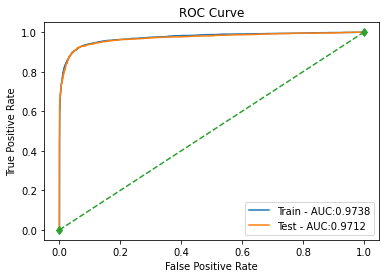

In [425]:
### plot ROC curve
fpr_train,tpr_train,thred_train = roc_curve(Ytr,EYtr_proba)
fpr_test,tpr_test,thred_test  = roc_curve(Yts,EYts_proba)

label = ['Train - AUC:{:.4f}'.format(auc(fpr_train,tpr_train)),
             'Test - AUC:{:.4f}'.format(auc(fpr_test,tpr_test))]
plt.plot(fpr_train,tpr_train)
plt.plot(fpr_test,tpr_test)
plt.plot([0,1],[0,1],'d--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(label, loc = 4)
plt.title('ROC Curve')


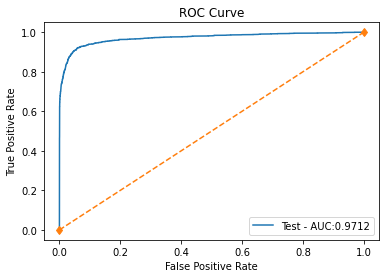

In [436]:
### plot test ROC curve
plt.plot(fpr_test,tpr_test)
plt.plot([0,1],[0,1],'d--')
plt.title('ROC Curve')
label = ['Test - AUC:{:.4f}'.format(auc(fpr_test,tpr_test))]
plt.legend(label, loc = 4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

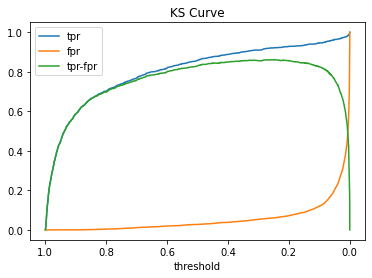

In [437]:
### plot test KS Curve
plt.plot(thred_test[1:],tpr_test[1:])
plt.plot(thred_test[1:],fpr_test[1:])
plt.plot(thred_test[1:],tpr_test[1:]-fpr_test[1:])
plt.title('KS Curve')
plt.legend(['tpr','fpr','tpr-fpr'])
plt.xlabel('threshold')
plt.gca().invert_xaxis()
plt.show()

In [412]:
tr_bucket = toad.metrics.KS_bucket(EYtr_proba,Ytr,bucket=10,method='quantile')
tr_bucket

,min,max,bads,goods,total,bad_rate,good_rate,odds,bad_prop,good_prop,total_prop,cum_bad_rate,cum_bad_rate_rev,cum_bads_prop,cum_bads_prop_rev,cum_goods_prop,cum_goods_prop_rev,cum_total_prop,cum_total_prop_rev,ks,lift,cum_lift
0,3.533168e-08,0.000187,11,2088,2099,0.005241,0.994759,0.005268,0.002532,0.125496,0.100033,0.005241,0.207072,0.002532,1.000000,0.125496,1.000000,0.100033,1.000000,0.122964,0.025308,1.000000
1,1.868079e-04,0.000941,13,2085,2098,0.006196,0.993804,0.006235,0.002992,0.125316,0.099986,0.005718,0.229506,0.005524,0.997468,0.250811,0.874504,0.200019,0.899967,0.245288,0.029924,1.108339
2,9.409542e-04,0.002599,12,2085,2097,0.005722,0.994278,0.005755,0.002762,0.125316,0.099938,0.005720,0.257417,0.008285,0.994476,0.376127,0.749189,0.299957,0.799981,0.367842,0.027635,1.243125
3,2.605553e-03,0.005972,17,2082,2099,0.008099,0.991901,0.008165,0.003913,0.125135,0.100033,0.006315,0.293349,0.012198,0.991715,0.501262,0.623873,0.399990,0.700043,0.489064,0.039112,1.416648
4,5.975273e-03,0.014063,27,2071,2098,0.012869,0.987131,0.013037,0.006214,0.124474,0.099986,0.007626,0.340905,0.018412,0.987802,0.625736,0.498738,0.499976,0.600010,0.607324,0.062149,1.646311
5,1.406866e-02,0.033398,54,2045,2099,0.025727,0.974273,0.026406,0.012428,0.122911,0.100033,0.010643,0.406500,0.030840,0.981588,0.748648,0.374264,0.600010,0.500024,0.717808,0.124239,1.963083
6,3.340132e-02,0.084625,78,2020,2098,0.037178,0.962822,0.038614,0.017952,0.121409,0.099986,0.014434,0.501728,0.048792,0.969160,0.870056,0.251352,0.699995,0.399990,0.821265,0.179542,2.422958
7,8.482391e-02,0.481532,388,1710,2098,0.184938,0.815062,0.226901,0.089298,0.102777,0.099986,0.035744,0.656553,0.138090,0.951208,0.972833,0.129944,0.799981,0.300005,0.834744,0.893108,3.170644
8,4.821850e-01,0.948961,1656,442,2098,0.789323,0.210677,3.746606,0.381128,0.026566,0.099986,0.119466,0.892304,0.519217,0.861910,0.999399,0.027167,0.899967,0.200019,0.480181,3.811822,4.309140
9,9.489758e-01,0.999703,2089,10,2099,0.995236,0.004764,208.900000,0.480783,0.000601,0.100033,0.207072,0.995236,1.000000,0.480783,1.000000,0.000601,1.000000,0.100033,-0.000000,4.806222,4.806222


In [452]:
card = toad.ScoreCard(combiner = combiner, transer = transer , C = 0.1, class_weight = 'balanced',
    base_score = 600,
    base_odds = 1/100 ,
    pdo = 50,
    rate = 2)
card.fit(Xtr, Ytr)
card1 = card.export(to_frame = True)
print(card1)

                    name                 value   score
0              loan_amnt       [-inf ~ 4025.0)  234.21
1              loan_amnt    [4025.0 ~ 11075.0)  113.30
2              loan_amnt   [11075.0 ~ 22375.0)   64.02
3              loan_amnt   [22375.0 ~ 33375.0)   56.51
4              loan_amnt   [33375.0 ~ 35075.0)   -4.38
5              loan_amnt       [35075.0 ~ inf)  227.91
6                   term           [-inf ~ 60)  102.86
7                   term            [60 ~ inf)   60.81
8             annual_inc      [-inf ~ 42891.0)   95.71
9             annual_inc   [42891.0 ~ 95100.0)   96.93
10            annual_inc  [95100.0 ~ 121070.0)   86.12
11            annual_inc      [121070.0 ~ inf)   74.84
12             out_prncp         [-inf ~ 0.01)   54.16
13             out_prncp          [0.01 ~ inf)  279.08
14       total_rec_prncp      [-inf ~ 4999.92)    3.18
15       total_rec_prncp   [4999.92 ~ 9999.96)   99.44
16       total_rec_prncp  [9999.96 ~ 19999.98)  188.36
17       t

In [453]:
def dict_type(card1):
    card1.score=card1.score.round()
    card1.value.fillna('nan',inplace=True)
    namelist=list(set(card1.name))
    myvalue=[]
    for var in namelist:
        ind_loc=card1.name==var
        value_dict = dict(zip(card1.value.loc[ind_loc],card1.score.loc[ind_loc]))
        myvalue=myvalue+[value_dict]
    big_dict = dict(zip(namelist,myvalue))
    return big_dict
    
# card2是四舍五入的新卡
card2 = dict_type(card1)

# 重新拟合card
card = toad.ScoreCard(combiner = combiner, transer = transer , card = card2,C = 0.1, class_weight = 'balanced',
    base_score = 600,
    base_odds = 1/100 ,
    pdo = 50,
    rate = 2)  
# 将评分卡结果导出并保存
final_card = card.export(to_frame=True,) 
final_card

,name,value,score
0,bc_open_to_buy,[-inf ~ 7475.0),103.0
1,bc_open_to_buy,[7475.0 ~ 15459.0),91.0
2,bc_open_to_buy,[15459.0 ~ 30437.0),69.0
3,bc_open_to_buy,[30437.0 ~ inf),49.0
4,annual_inc,[-inf ~ 42891.0),96.0
5,annual_inc,[42891.0 ~ 95100.0),97.0
6,annual_inc,[95100.0 ~ 121070.0),86.0
7,annual_inc,[121070.0 ~ inf),75.0
8,last_fico_range_high,[-inf ~ 554.0),-93.0
9,last_fico_range_high,[554.0 ~ 599.0),-40.0


In [516]:
#得到样本的最终评分
final_score=pd.DataFrame(card.predict(data_ts),index=data_ts.index,columns=['score'])
final_score.describe()

,score
count,8993.000000
mean,1084.819415
std,260.658492
min,427.000000
25%,929.000000
50%,1124.000000
75%,1258.000000
max,1854.000000


In [517]:
data_score = pd.concat([final_test,final_score],axis = 1)

In [518]:
data_score

,loan_amnt,term,annual_inc,out_prncp,total_rec_prncp,last_pymnt_amnt,last_fico_range_high,total_bal_il,bc_open_to_buy,pct_tl_nvr_dlq,loan_status,score
26665,0.119494,-0.149140,-0.082986,0.424740,-1.029788,0.707684,-2.550743,-0.196696,-0.335932,-0.084628,0,1051.0
23520,0.119494,0.370712,-0.283001,0.424740,-2.565026,-5.069565,-1.028658,-0.187272,0.010294,-0.016925,0,1367.0
6031,0.424693,0.370712,-0.283001,-2.182732,-1.029788,-1.151199,-2.550743,-0.187272,0.010294,-0.016925,0,1269.0
215,0.152977,0.370712,0.108829,0.424740,-2.565026,0.707684,-1.972149,0.327248,0.190271,0.332538,0,1136.0
18224,-0.100402,-0.149140,0.087153,0.424740,-0.091265,-2.750192,-2.550743,0.327248,0.010294,-0.016925,0,1232.0
...,...,...,...,...,...,...,...,...,...,...,...,...
14598,-0.100402,-0.149140,0.108829,-2.182732,0.924844,0.388079,-1.028658,-0.196696,0.190271,-0.084628,0,1107.0
15052,-0.100402,-0.149140,0.108829,0.424740,-0.091265,-2.750192,-1.028658,-0.196696,0.190271,-0.016925,0,1135.0
17941,-0.100402,0.370712,-0.283001,0.424740,-1.029788,-2.750192,-1.028658,0.327248,0.190271,-0.084628,0,1181.0
29448,0.424693,-0.149140,-0.283001,0.424740,-2.565026,0.707684,-1.028658,-0.187272,-0.335932,-0.016925,0,1018.0


In [519]:
def cal_df(data, cut_num, feature, target):
    # 1、数据分箱（等宽）
    data_cut = pd.cut(data[feature], cut_num)
    # 2、统计各个分箱的总样本数、违约样本数和不违约样本数
    cut_group_all = data[target].groupby(data_cut).count()#总样本数
    cut_y = data[target].groupby(data_cut).sum() #违约样本数
    cut_n = cut_group_all - cut_y #未违约样本数
    # 3、汇总基础数据
    df = pd.DataFrame() #创建空DataFrame用来汇总数据
    df['总数'] = cut_group_all
    df['违约'] = cut_y
    df['未违约'] = cut_n
    # 4、统计违约数比率
    
    df['违约率%'] = df['违约'] / df['总数']
    df['违约率%'] = df['违约率%'].apply(lambda x: format(x, '.2%'))
   
    return df

In [520]:
#训练集
score_card = cal_df(data_score, 10, 'score', 'loan_status')
score_card

,总数,违约,未违约,违约率%
score,,,,
"(425.573, 569.7]",319,319,0,100.00%
"(569.7, 712.4]",784,772,12,98.47%
"(712.4, 855.1]",763,511,252,66.97%
"(855.1, 997.8]",849,161,688,18.96%
"(997.8, 1140.5]",2062,51,2011,2.47%
"(1140.5, 1283.2]",2331,27,2304,1.16%
"(1283.2, 1425.9]",1175,7,1168,0.60%
"(1425.9, 1568.6]",577,3,574,0.52%
"(1568.6, 1711.3]",124,0,124,0.00%
